# Sperimentazione Algoritmo Genetico per Churn Prevention
In questo notebook testiamo il GA sui 4 profili paziente (Ghost, A Rischio, Moderato, Engaged) per verificare come l'algoritmo sviluppi strategie di nudging differenziate.

In [43]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

# Aggiungiamo il percorso dei sorgenti
sys.path.append('../src')
from genetic_algorithm import GAParams, GeneticAlgorithm

# Caricamento del dataset processato
df = pd.read_csv('../data/processed/churn_features.csv')
print(f"Dataset caricato: {len(df)} pazienti.")
df.head()


Dataset caricato: 500 pazienti.


,id_paziente,profilo_assegnato,mood_frequency_7d,mood_consistency_7d,avg_mood_valence_7d,diary_entries_7d,avg_diary_length_7d,questionnaire_compliance,forum_activity_7d,notification_read_rate,days_in_waitlist,badges_total,night_activity_rate
0,d5ca6757-72de-4f90-aef0-edc13e6283a2,Ghost,0.000000,0.000000,0.464286,0.000000,0.000000,0.0,0.0,0.066667,0.590909,0.000000,0.0
1,a23c83a4-b4fb-4294-8363-2f2d668ba684,Engaged,0.714286,0.714286,0.475000,0.714286,0.404833,1.0,1.0,0.400000,0.113636,0.733333,0.1
2,54384c79-9187-4cfa-a145-3ad727e1c295,Ghost,0.000000,0.000000,0.464286,0.000000,0.000000,0.0,0.0,0.200000,0.659091,0.000000,0.0
3,fb1e6974-96e9-4c91-af95-ee9dc88e33e1,Engaged,0.857143,0.857143,0.758929,0.714286,0.718764,1.0,0.0,0.733333,0.681818,0.600000,0.0
4,500de50b-bb3e-44ef-a833-bab5e377e8af,Engaged,1.000000,1.000000,0.563776,0.571429,0.806104,1.0,0.0,0.866667,0.772727,0.466667,0.0


## Funzione di Utilità

In [44]:
def run_and_plot(profile_name, save_fig=True):
    print(f"\n{'='*60}")
    print(f"ESECUZIONE GA - PROFILO: {profile_name.upper()}")
    print(f"{'='*60}")
    
    # Selezione del primo paziente corrispondente al profilo
    patient = df[df['profilo_assegnato'] == profile_name].iloc[0]
    print("\n--- Feature Comportamentali --- ")
    print(patient[['mood_frequency_7d', 'avg_mood_valence_7d', 'notification_read_rate', 'badges_total']])
    
    # Configurazione e Avvio GA
    params = GAParams(generations=150, pop_size=100)
    ga = GeneticAlgorithm(params, patient)
    best = ga.run()
    
    print("\n--- Migliore Strategia Evoluta ---")
    print(f"Fitness: {best.fitness:.4f}")
    phenotype = best.decode()
    for k, v in phenotype.items():
        print(f"  {k}: {v}")
        
    # Creazione dei Grafici
    plt.figure(figsize=(10, 4))
    
    # Plot 1: Convergenza Fitness
    plt.subplot(1, 2, 1)
    plt.plot(ga.history_best, label='Migliore', color='blue', linewidth=2)
    plt.plot(ga.history_avg, label='Media', color='skyblue', linestyle='--')
    plt.title(f'Fitness ({profile_name})')
    plt.xlabel('Generazioni')
    plt.ylabel('Fitness')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Diversità Genetica
    plt.subplot(1, 2, 2)
    plt.plot(ga.history_diversity, color='orange', label='Hamming Distance')
    plt.title('Diversità Genetica')
    plt.xlabel('Generazioni')
    plt.ylabel('Distanza')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
        # Salvataggio per il documento LaTeX
    if save_fig:
        # Percorso RELATIVO: sale di 3 livelli dalla cartella notebooks/ alla root e scende in docs/
        # Funziona su ogni PC perché basato sulla struttura del repository
        fig_dir = os.path.join("..", "..", "..", "docs", "latex", "figures")
        os.makedirs(fig_dir, exist_ok=True)
        
        # Normalizziamo il nome per il LaTeX
        clean_name = profile_name.lower().replace(' ', '')
        filename = f"ga_convergence_{clean_name}.png"
        filepath = os.path.join(fig_dir, filename)
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"\n[OK] Immagine salvata: {filepath}")



## Test sui 4 Profili

2026-03-10 19:52:12,359 - INFO - Avvio Algoritmo Genetico...
2026-03-10 19:52:12,372 - INFO - Gen 001 | Best: 0.9000 | Avg: 0.2335 | Div: 0.4837
2026-03-10 19:52:12,398 - INFO - Gen 010 | Best: 1.0000 | Avg: 0.9525 | Div: 0.1818



ESECUZIONE GA - PROFILO: GHOST

--- Feature Comportamentali --- 
mood_frequency_7d              0.0
avg_mood_valence_7d       0.464286
notification_read_rate    0.066667
badges_total                   0.0
Name: 0, dtype: object


2026-03-10 19:52:12,422 - INFO - Convergenza raggiunta (plateau variance < 1e-6) alla generazione 17. Arresto anticipato.



--- Migliore Strategia Evoluta ---
Fitness: 1.0000
  tipologia: Motivazionale
  frequenza_settimanale: 1
  orari_attivi: [7, 8, 9, 10, 11, 13, 14, 17, 18, 19, 22]
  distribuzione: Concentrata


2026-03-10 19:52:12,765 - INFO - Avvio Algoritmo Genetico...
2026-03-10 19:52:12,771 - INFO - Gen 001 | Best: 0.9250 | Avg: 0.4590 | Div: 0.4848
2026-03-10 19:52:12,792 - INFO - Gen 010 | Best: 1.0000 | Avg: 0.9546 | Div: 0.2017
2026-03-10 19:52:12,809 - INFO - Convergenza raggiunta (plateau variance < 1e-6) alla generazione 17. Arresto anticipato.



[OK] Immagine salvata: ..\..\..\docs\latex\figures\ga_convergence_ghost.png

ESECUZIONE GA - PROFILO: A RISCHIO

--- Feature Comportamentali --- 
mood_frequency_7d              0.0
avg_mood_valence_7d       0.464286
notification_read_rate    0.333333
badges_total              0.266667
Name: 8, dtype: object

--- Migliore Strategia Evoluta ---
Fitness: 1.0000
  tipologia: Motivazionale
  frequenza_settimanale: 4
  orari_attivi: [7, 11, 12, 13, 14, 16, 17, 19, 21]
  distribuzione: Uniforme


2026-03-10 19:52:13,096 - INFO - Avvio Algoritmo Genetico...
2026-03-10 19:52:13,103 - INFO - Gen 001 | Best: 0.8833 | Avg: 0.4368 | Div: 0.4871
2026-03-10 19:52:13,124 - INFO - Gen 010 | Best: 0.9000 | Avg: 0.8770 | Div: 0.1043
2026-03-10 19:52:13,143 - INFO - Convergenza raggiunta (plateau variance < 1e-6) alla generazione 17. Arresto anticipato.



[OK] Immagine salvata: ..\..\..\docs\latex\figures\ga_convergence_arischio.png

ESECUZIONE GA - PROFILO: MODERATO

--- Feature Comportamentali --- 
mood_frequency_7d         0.428571
avg_mood_valence_7d       0.482143
notification_read_rate         0.6
badges_total                   0.3
Name: 5, dtype: object

--- Migliore Strategia Evoluta ---
Fitness: 0.9000
  tipologia: Questionario
  frequenza_settimanale: 4
  orari_attivi: [7, 9, 15, 16, 19, 20, 22]
  distribuzione: Concentrata


2026-03-10 19:52:13,450 - INFO - Avvio Algoritmo Genetico...
2026-03-10 19:52:13,457 - INFO - Gen 001 | Best: 0.8550 | Avg: 0.4461 | Div: 0.4825
2026-03-10 19:52:13,480 - INFO - Gen 010 | Best: 0.9000 | Avg: 0.8689 | Div: 0.1958
2026-03-10 19:52:13,497 - INFO - Convergenza raggiunta (plateau variance < 1e-6) alla generazione 17. Arresto anticipato.



[OK] Immagine salvata: ..\..\..\docs\latex\figures\ga_convergence_moderato.png

ESECUZIONE GA - PROFILO: ENGAGED

--- Feature Comportamentali --- 
mood_frequency_7d         0.714286
avg_mood_valence_7d          0.475
notification_read_rate         0.4
badges_total              0.733333
Name: 1, dtype: object

--- Migliore Strategia Evoluta ---
Fitness: 0.9000
  tipologia: Questionario
  frequenza_settimanale: 5
  orari_attivi: [7, 9, 10, 13, 14, 16, 18, 20]
  distribuzione: Concentrata

[OK] Immagine salvata: ..\..\..\docs\latex\figures\ga_convergence_engaged.png


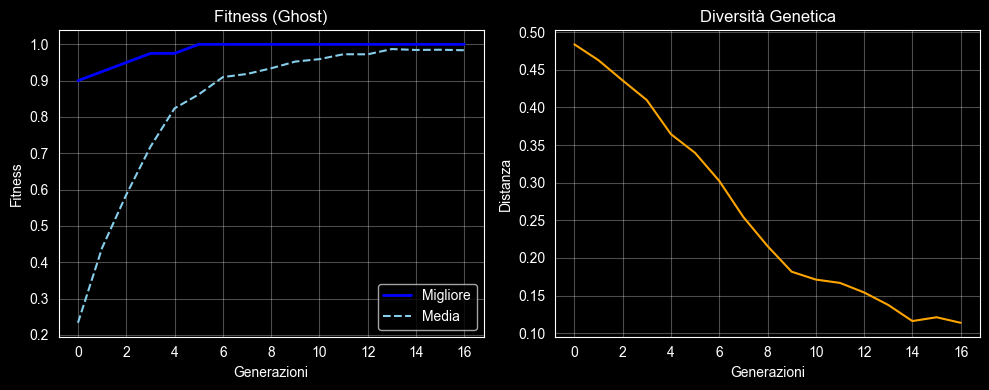

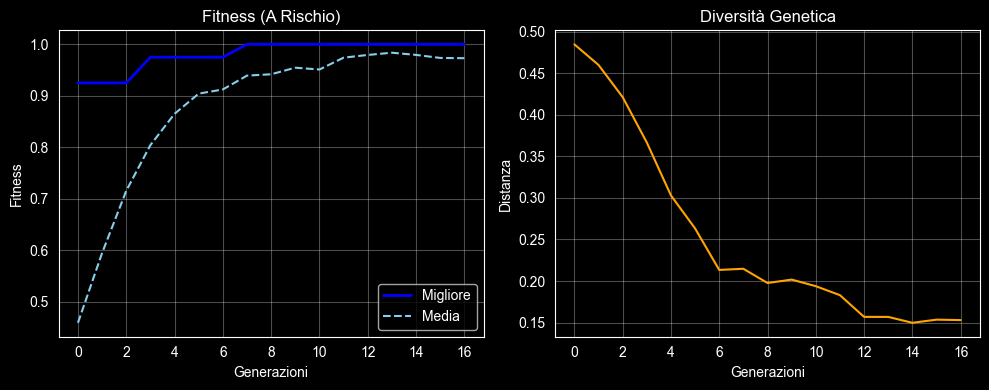

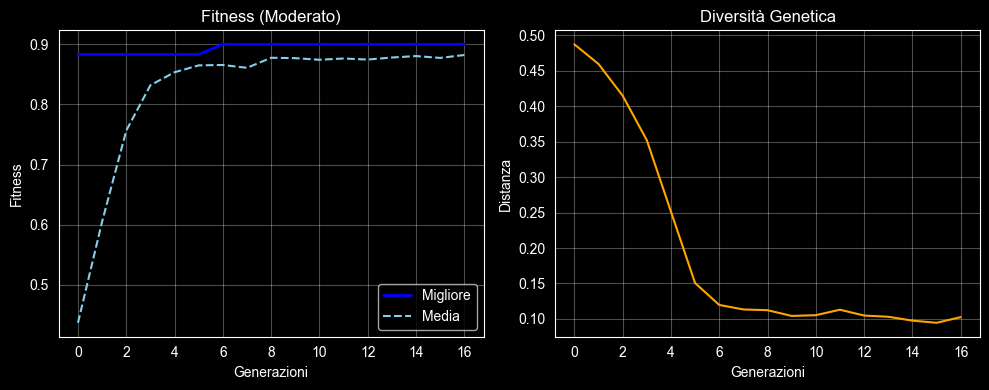

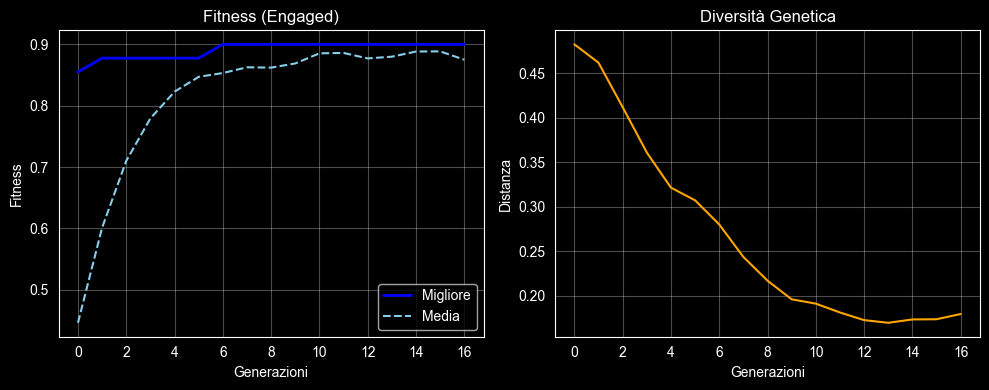

In [45]:
# Lista dei profili da analizzare
profili = ['Ghost', 'A Rischio', 'Moderato', 'Engaged']

for p in profili:
    run_and_plot(p)
